# The second case: where revenue comes from, solution

**Week 1, Monday, afternoon. The second case, in pairs, 25 minutes.** The six chapters and the escalated case said
frequency first. This notebook answers the other half of Meera's question on the same 30 orders,
1 July to 26 September 2026, and tests whether the channel view changes that recommendation.

Meera Raghavan, CEO of Kalpa Retail: "Where does revenue come from, by customer type and channel? Is
acquisition even the branch that is short?" Anand Iyer, the finance controller: "No averages. One
business customer can move an average."

> **Kavya's review.** "Meera will open the channel slide before she reads your sentence, and the first
> thing on it will be store at nine rupees in ten. Decide whether that number changes your answer
> before she asks, and count the orders behind every share you show her."

Every placeholder is filled with the right option, and the notebook was executed from a fresh kernel. Under each step sits the reason the other three options fail, and step 1 stages the plausible wrong answer with its exact number.

**The answer string:** `cbdabca`.

The setup cell reaches the shared helper and loads the 30 orders, converting the amount stored as
text with `int()` as chapter 1 did.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

ORDERS = kit.load_records()
for order in ORDERS:
    order["amount"] = int(order["amount"])
print(len(ORDERS), "orders loaded, every amount now a whole number")
booked_revenue = 0
for order in ORDERS:
    booked_revenue += order["amount"]
print("booked revenue summed for the shares below")

30 orders loaded, every amount now a whole number
booked revenue summed for the shares below


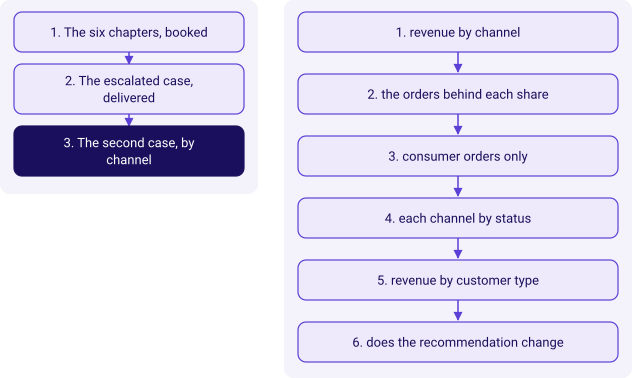

In [2]:
kit.side_by_side(
    kit.ladder(["The six chapters, booked", "The escalated case, delivered", "The second case, by channel"],
               lit=2, show=False),
    kit.vflow(["1. revenue by channel", "2. the orders behind each share",
               "3. consumer orders only", "4. each channel by status",
               "5. revenue by customer type", "6. does the recommendation change"], show=False),
)

## Step 1. Revenue by channel

Add each order's amount to its channel's total, then work out store's share of booked revenue.

**Post:** each channel's share of booked revenue, and store's in particular.

Channel,Orders,Share of booked revenue
app,10,3.4%
web,10,5.0%
store,10,91.6%


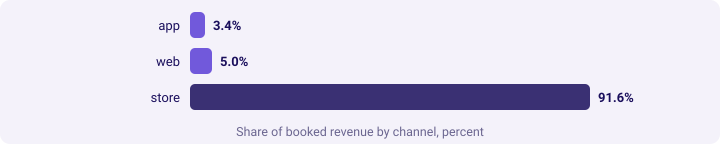

In [3]:
channel_revenue = {}
channel_orders = {}
for order in ORDERS:
    ch = order["channel"]
    # TODO 1. Which line adds this order's amount to its channel's total?
    #   a) channel_revenue[ch] = order["amount"]
    #   b) channel_revenue[ch] = channel_revenue.get(ch, 0) + 1
    #   c) channel_revenue[ch] = channel_revenue.get(ch, 0) + order["amount"]
    #   d) channel_revenue[ch] = channel_revenue.get(ch, order["amount"]) + order["amount"]
    channel_revenue[ch] = channel_revenue.get(ch, 0) + order["amount"]
    channel_orders[ch] = channel_orders.get(ch, 0) + 1

# TODO 2. Which expression is store's share of booked revenue?
#   a) channel_revenue["store"] / len(ORDERS)
#   b) channel_revenue["store"] / booked_revenue
#   c) channel_orders["store"] / len(ORDERS)
#   d) channel_revenue["store"] / channel_revenue["app"]
store_share = channel_revenue["store"] / booked_revenue

channels = ["app", "web", "store"]
kit.table(["Channel", "Orders", "Share of booked revenue"],
          [(ch, channel_orders[ch], f"{channel_revenue[ch] / booked_revenue * 100:.1f}%")
           for ch in channels],
          caption="Share of booked revenue by channel, all 30 orders")
kit.bars([(ch, round(channel_revenue[ch] / booked_revenue * 1000) / 10) for ch in channels],
         fmt=lambda v: f"{v:.1f}%", lit=(2,), title="Share of booked revenue by channel, percent")

In [4]:
kit.check("the channels reconcile to booked revenue", sum(channel_revenue.values()) == booked_revenue)
kit.check("each channel carries the same number of orders",
          len(set(channel_orders.values())) == 1, str(channel_orders))
kit.check("store's share is a fraction of booked revenue", 0 < store_share < 1,
          f"{store_share * 100:.1f} percent")

**Why not the others.** In TODO 1, option a overwrites the total with the latest order; b counts
orders instead of adding rupees; d starts each channel at its first amount and then adds it again, so
every channel's first order counts twice. In TODO 2, option a is revenue per order in the store; c is
store's share of orders, one third; d compares store with app, a ratio with no whole behind it.

**The plausible wrong answer.** "Store brings 91.6 percent of revenue, so the growth plan should be
store-led."

**Why it is wrong.** Every channel has 10 orders, yet store's share is nine rupees in ten. A share
that large from a third of the orders means a few orders carry it, and Anand has already said one
business customer can move an average; a share is an average in disguise.

**The check that catches it.** Count the orders behind each share and split them by status, which is
step 2.

## Step 2. The orders behind each share

Count each channel's orders by status, and count the orders in each channel that sit above the booked
mean of Rs 18,160.

**Post:** each channel's delivered, returned and cancelled counts, and the orders above the mean.

Channel,Delivered,Returned,Cancelled,Orders above the mean
app,10,0,0,0
web,5,5,0,0
store,6,0,4,1


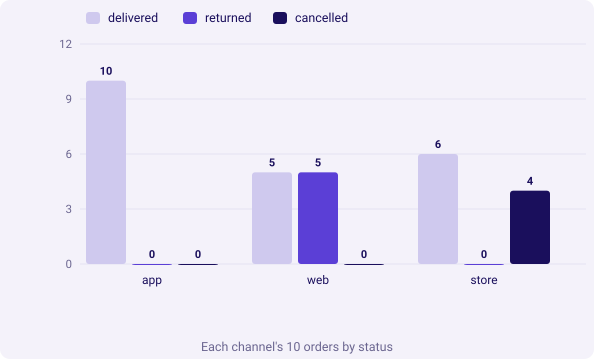

In [5]:
status_count = {"app": {}, "web": {}, "store": {}}
for order in ORDERS:
    ch = order["channel"]
    st = order["status"]
    # TODO 3. Which line counts this order under its channel and its status?
    #   a) status_count[ch] = status_count.get(ch, 0) + 1
    #   b) status_count[st][ch] = status_count[st].get(ch, 0) + 1
    #   c) status_count[ch][st] = status_count[ch].get(st, 0) + order["amount"]
    #   d) status_count[ch][st] = status_count[ch].get(st, 0) + 1
    status_count[ch][st] = status_count[ch].get(st, 0) + 1

mean_order = booked_revenue / len(ORDERS)
above_mean = {"app": 0, "web": 0, "store": 0}
for order in ORDERS:
    if order["amount"] > mean_order:
        above_mean[order["channel"]] += 1

statuses = ["delivered", "returned", "cancelled"]
kit.table(["Channel", "Delivered", "Returned", "Cancelled", "Orders above the mean"],
          [(ch, *[status_count[ch].get(st, 0) for st in statuses], above_mean[ch]) for ch in channels],
          caption="Orders, not rupees, behind each channel's share")
kit.columns(channels, [(st, [status_count[ch].get(st, 0) for ch in channels]) for st in statuses],
            title="Each channel's 10 orders by status", fmt=lambda v: f"{v:.0f}")

In [6]:
kit.check("the status counts add back to 30 orders",
          sum(sum(c.values()) for c in status_count.values()) == len(ORDERS))
kit.check("store's share rests on a single order above the mean", above_mean["store"] == 1,
          f"{above_mean['store']} order")
kit.check("every returned order came through one channel",
          sum(1 for ch in channels if status_count[ch].get("returned", 0) > 0) == 1)

**Why not the others.** Option a counts orders per channel and loses the status; b indexes the
dictionary by status first, and `status_count["delivered"]` does not exist, so it raises a
`KeyError`; c adds rupees where the step asks for counts.

**What it shows.** App's 10 orders were all delivered. Web delivered 5 and saw 5 returned. Store
delivered 6 and had 4 cancelled, and exactly one store order sits above the booked mean: the order
your chapter 4 sort put at the top, which belongs to the one Business customer. Store's nine rupees in
ten is one order's share.

## Step 3. The fix: consumer orders only

Meera's growth plan is about the customers who buy again and again, so recompute the channel view on
the consumer orders, the 29 outside the Business segment.

**Post:** consumer booked revenue, and each channel's consumer revenue and share.

Channel,Consumer orders,Consumer revenue,Share of consumer
app,10,"Rs 18,600",28.7%
web,10,"Rs 27,290",42.1%
store,9,"Rs 18,920",29.2%


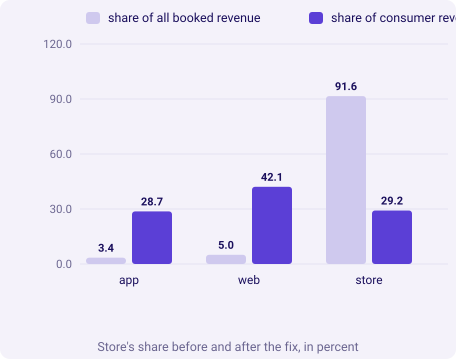

In [7]:
# TODO 4. Which condition keeps the consumer orders, the 29 outside the Business segment?
#   a) order["segment"] != "Business"
#   b) order["segment"] == "Retail-Core"
#   c) order["channel"] != "store"
#   d) order["status"] != "cancelled"
consumer = []
for order in ORDERS:
    if order["segment"] != "Business":
        consumer.append(order)

consumer_revenue = 0
consumer_channel_rev = {"app": 0, "web": 0, "store": 0}
consumer_channel_orders = {"app": 0, "web": 0, "store": 0}
for order in consumer:
    consumer_revenue += order["amount"]
    consumer_channel_rev[order["channel"]] += order["amount"]
    consumer_channel_orders[order["channel"]] += 1

kit.table(["Channel", "Consumer orders", "Consumer revenue", "Share of consumer"],
          [(ch, consumer_channel_orders[ch], kit.rupees(consumer_channel_rev[ch]),
            f"{consumer_channel_rev[ch] / consumer_revenue * 100:.1f}%") for ch in channels],
          caption=f"{len(consumer)} consumer orders, {kit.rupees(consumer_revenue)} booked")
kit.columns(channels, [("share of all booked revenue",
                        [channel_revenue[ch] / booked_revenue * 100 for ch in channels]),
                       ("share of consumer revenue",
                        [consumer_channel_rev[ch] / consumer_revenue * 100 for ch in channels])],
            title="Store's share before and after the fix, in percent", fmt=lambda v: f"{v:.1f}")

In [8]:
kit.check("29 consumer orders remain", len(consumer) == 29, f"got {len(consumer)}")
kit.check("the consumer channels reconcile to consumer revenue",
          sum(consumer_channel_rev.values()) == consumer_revenue, kit.rupees(consumer_revenue))
kit.check("on consumer orders store no longer leads",
          consumer_channel_rev["store"] < max(consumer_channel_rev.values()))

**Why not the others.** Option b keeps one consumer segment and drops the other two; c drops every
store order, including the nine consumer ones; d applies a status definition, which answers a
different question and still keeps the Business order.

**The fix, and what changed.** On the 29 consumer orders, Rs 64,810 booked, web leads with Rs 27,290
(42.1 percent), store has Rs 18,920 (29.2 percent) and app Rs 18,600 (28.7 percent). The channel that
looked like nine rupees in ten is under a third of consumer revenue.

## Step 4. Each channel by status, in rupees

Booked is what customers asked for; delivered is what stayed sold. Split each channel's consumer
revenue by status and find where it leaks.

**Post:** web's returned revenue, store's cancelled revenue, and consumer delivered revenue.

Channel,Delivered,Returned,Cancelled
app,"Rs 18,600",Rs 0,Rs 0
web,"Rs 12,320","Rs 14,970",Rs 0
store,"Rs 9,870",Rs 0,"Rs 9,050"


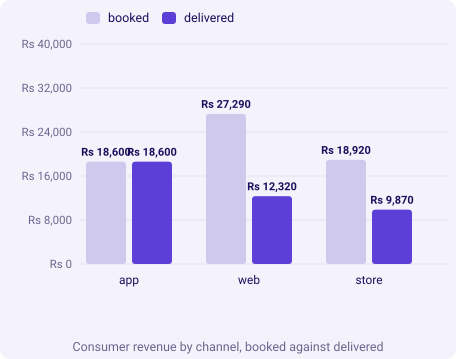

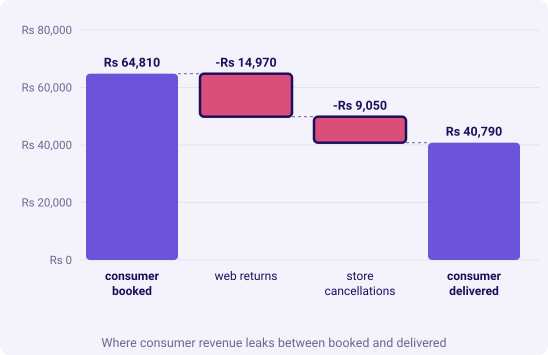

In [9]:
consumer_status_rev = {"app": {}, "web": {}, "store": {}}
for order in consumer:
    ch = order["channel"]
    st = order["status"]
    consumer_status_rev[ch][st] = consumer_status_rev[ch].get(st, 0) + order["amount"]

# TODO 5. Which number is web's leak, the booked revenue that came back?
#   a) consumer_status_rev["web"].get("delivered", 0)
#   b) consumer_status_rev["web"].get("returned", 0)
#   c) consumer_status_rev["store"].get("returned", 0)
#   d) consumer_channel_rev["web"] - consumer_status_rev["web"].get("returned", 0)
web_leak = consumer_status_rev["web"].get("returned", 0)
store_leak = consumer_status_rev["store"].get("cancelled", 0)
consumer_delivered = 0
for ch in channels:
    consumer_delivered += consumer_status_rev[ch].get("delivered", 0)

kit.table(["Channel", "Delivered", "Returned", "Cancelled"],
          [(ch, *[kit.rupees(consumer_status_rev[ch].get(st, 0)) for st in statuses])
           for ch in channels], caption="Consumer revenue by channel and status")
kit.columns(channels, [("booked", [consumer_channel_rev[ch] for ch in channels]),
                       ("delivered", [consumer_status_rev[ch].get("delivered", 0) for ch in channels])],
            title="Consumer revenue by channel, booked against delivered", fmt=kit.rupees)
kit.bridge(("consumer booked", consumer_revenue),
           [("web returns", -web_leak), ("store cancellations", -store_leak)],
           end_label="consumer delivered", lit=(0, 1),
           title="Where consumer revenue leaks between booked and delivered")

In [10]:
kit.check("booked less the two leaks lands on delivered",
          consumer_revenue - web_leak - store_leak == consumer_delivered, kit.rupees(consumer_delivered))
kit.check("app delivered every rupee it booked",
          consumer_status_rev["app"].get("delivered", 0) == consumer_channel_rev["app"])
kit.check("web lost more than a third of its booked revenue to returns",
          web_leak > consumer_channel_rev["web"] / 3, kit.rupees(web_leak))

**Why not the others.** Option a is what web kept; c looks for returns in store, which has none; d is
web's booked revenue less its returns, which is again what web kept.

**What it shows.** Web booked Rs 27,290 and half its orders came back, Rs 14,970 returned, leaving
Rs 12,320 delivered. Store's consumer orders booked Rs 18,920, and 4 of its 9 were cancelled for
Rs 9,050, leaving Rs 9,870 delivered. App booked Rs 18,600 and delivered all of it, 10 of 10. Consumer
delivered revenue is Rs 40,790.

## Step 5. Revenue by customer type

Meera also asked about customer type. Segment is recorded on each order, so this step stays at
orders and revenue by segment: one repeat customer appears once as Retail-Core and once as Retail-Plus,
and a count of customers per segment would count that customer twice. The Business segment is one
order, so its row carries the count and the rupee view stays on the three consumer segments.

**Post:** each consumer segment's orders, revenue and share of consumer revenue.

Customer type,Orders,Booked revenue,Share of consumer,Revenue per order
Retail-Core,14,"Rs 32,650",50.4%,"Rs 2,332"
Retail-Plus,10,"Rs 27,320",42.2%,"Rs 2,732"
Student,5,"Rs 4,840",7.5%,Rs 968
Business,1,outside the consumer view,outside the consumer view,outside the consumer view


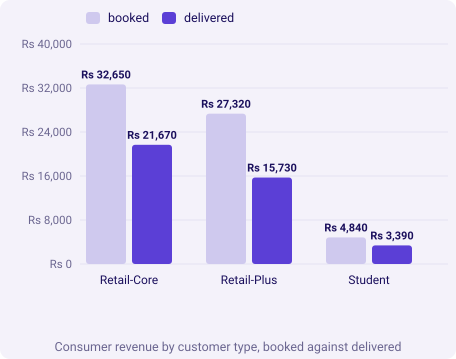

In [11]:
segment_orders = {}
for order in ORDERS:
    segment_orders[order["segment"]] = segment_orders.get(order["segment"], 0) + 1

segment_rev = {}
segment_delivered = {}
for order in consumer:
    seg = order["segment"]
    segment_rev[seg] = segment_rev.get(seg, 0) + order["amount"]
    if order["status"] == "delivered":
        segment_delivered[seg] = segment_delivered.get(seg, 0) + order["amount"]

# TODO 6. Which total is the denominator for a segment's share of consumer revenue?
#   a) booked_revenue
#   b) len(consumer)
#   c) consumer_revenue
#   d) segment_rev["Retail-Core"]
denominator = consumer_revenue

segments = ["Retail-Core", "Retail-Plus", "Student"]
rows = [(seg, segment_orders[seg], kit.rupees(segment_rev[seg]),
         f"{segment_rev[seg] / denominator * 100:.1f}%",
         kit.rupees(round(segment_rev[seg] / segment_orders[seg]))) for seg in segments]
rows.append(("Business", segment_orders["Business"], "outside the consumer view",
             "outside the consumer view", "outside the consumer view"))
kit.table(["Customer type", "Orders", "Booked revenue", "Share of consumer", "Revenue per order"],
          rows, caption="Revenue by customer type, recorded on each order")
kit.columns(segments, [("booked", [segment_rev[seg] for seg in segments]),
                       ("delivered", [segment_delivered[seg] for seg in segments])],
            title="Consumer revenue by customer type, booked against delivered", fmt=kit.rupees)

In [12]:
kit.check("the four segments account for all 30 orders", sum(segment_orders.values()) == len(ORDERS))
kit.check("the consumer segments reconcile to consumer revenue",
          sum(segment_rev.values()) == consumer_revenue, kit.rupees(sum(segment_rev.values())))
kit.check("the shares of consumer revenue add to one",
          abs(sum(segment_rev[s] / denominator for s in segments) - 1) < 1e-9)

**Why not the others.** Option a divides by a total that includes the Business order, so the three
consumer shares add to about 12 percent; b divides rupees by orders, which is revenue per order; d
indexes every segment to Retail-Core, so Retail-Core reads 100 percent.

**What it shows.** Retail-Core placed 14 orders for Rs 32,650 (50.4 percent of consumer revenue),
Retail-Plus 10 for Rs 27,320 (42.2 percent) and Student 5 for Rs 4,840 (7.5 percent); Business is
1 order. Retail-Plus, the paid tier, has the highest revenue per order at Rs 2,732, and 3 of its 10
orders came back, which is a question for the head of Retail-Plus on Tuesday.

## Step 6. Does one channel change the recommendation?

The escalated case said open frequency first. Weigh that against what the channel view found.

the recommendation: frequency first, two leaks named


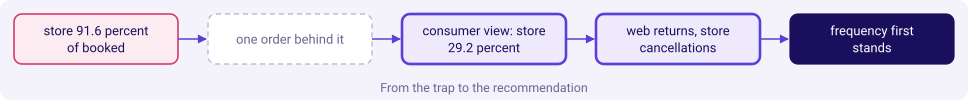

In [13]:
# TODO 7. What does the channel view do to the recommendation?
#   a) "frequency first, two leaks named"
#   b) "store-led, since store brings 91.6 percent"
#   c) "web-led"
#   d) "acquisition first"
verdict = "frequency first, two leaks named"
print("the recommendation:", verdict)
kit.flow(["store 91.6 percent of booked", "one order behind it", "consumer view: store 29.2 percent",
          "web returns, store cancellations", "frequency first stands"],
         kinds=["bad", "unknown", "known", "known", "lit"],
         title="From the trap to the recommendation")

In [14]:
kit.check("the recommendation keeps the branch and names the leaks", verdict.startswith("frequency"),
          verdict)

**Why not the others.** Option b is the trap, a share that one order carries; c reads web's booked
lead and ignores that half its orders came back; d moves to the branch the file gave no reason to
open first.

**The conclusion.** The branch recommendation stands: open frequency first. The channel view adds two
leaks for the note: web returns, 5 of 10 orders and Rs 14,970, and store cancellations, 4 orders and
Rs 9,050. App is the clean channel, 10 of 10 delivered.

> **Kavya's review.** "Good: you counted the orders behind the share before you believed it. The
> channel slide now carries two leaks with their numbers, and your sentence to Meera does not change."

### In the interview

**[D] One channel carries nine rupees in ten of revenue; does that change where the growth plan
invests?** Not before I count the orders behind the share. At Kalpa, store's 91.6 percent rests on one
Business order; on the 29 consumer orders store holds Rs 18,920 of Rs 64,810, 29.2 percent, and 4 of
its 9 consumer orders were cancelled. So the plan still invests on the branch the tree points to,
frequency, and the channel view adds the leaks to fix: web returns and store cancellations.

**[F] A business says 'grow revenue 15 percent'; how do you turn that into questions data can
answer?** I turn it into counts and ratios. Which revenue, booked, net of cancellations or delivered?
Over which two windows? Which branch is short: customers, orders per customer or revenue per order?
What does 15 percent need from one branch alone, which on Kalpa's quarter is about 3.45 more customers,
or 4.5 more orders from the same 23 customers, or Rs 2,724 more per order? And which customer types
and channels carry the revenue, and where does it leak before delivery?

## What the second case established

Six steps, and the recommendation survives the channel view with two leaks added to the note.

Step,What it established
1. by channel,store carries 91.6 percent of booked revenue
2. orders behind it,1 store order sits above the mean; store cancelled 4
3. consumer only,"store holds Rs 18,920 of Rs 64,810"
4. by status,"web returned Rs 14,970; store cancelled Rs 9,050; app delivered 10 of 10"
5. by customer type,"Retail-Core Rs 32,650, Retail-Plus Rs 27,320, Student Rs 4,840"
6. the recommendation,"frequency first, two leaks named"


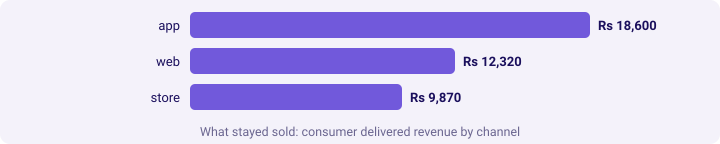

In [15]:
kit.table(["Step", "What it established"], [
    ("1. by channel", f"store carries {store_share * 100:.1f} percent of booked revenue"),
    ("2. orders behind it", f"{above_mean['store']} store order sits above the mean; "
                            f"store cancelled {status_count['store'].get('cancelled', 0)}"),
    ("3. consumer only", f"store holds {kit.rupees(consumer_channel_rev['store'])} of "
                         f"{kit.rupees(consumer_revenue)}"),
    ("4. by status", f"web returned {kit.rupees(web_leak)}; store cancelled {kit.rupees(store_leak)}; "
                     f"app delivered {status_count['app'].get('delivered', 0)} of 10"),
    ("5. by customer type", f"Retail-Core {kit.rupees(segment_rev['Retail-Core'])}, Retail-Plus "
                            f"{kit.rupees(segment_rev['Retail-Plus'])}, Student "
                            f"{kit.rupees(segment_rev['Student'])}"),
    ("6. the recommendation", verdict),
])
kit.bars([(ch, consumer_status_rev[ch].get("delivered", 0)) for ch in channels], fmt=kit.rupees,
         title="What stayed sold: consumer delivered revenue by channel")

In [16]:
kit.check_summary()
print("Next: Tuesday puts the quarter before this one beside it, to see which branch moved.")

Next: Tuesday puts the quarter before this one beside it, to see which branch moved.
